<div dir="rtl" style="text-align: justify; line-height: 1.8;">

### تمرین ۳: سیستم ردیابی مبتنی بر ویژگی (Feature-based Tracking)

در این تمرین، یک سیستم ردیابی اشیاء در ویدیو با استفاده از جریان نوری (Optical Flow) پیاده‌سازی شده است. مراحل انجام کار به شرح زیر است:

1. **تشخیص ویژگی‌های پایدار (فریم اول):** از الگوریتم **Shi-Tomasi** (`cv2.goodFeaturesToTrack`) استفاده شده است. این الگوریتم نسبت به Harris برای ردیابی پایدارتر است و نقاطی را انتخاب می‌کند که کمترین تغییرات را در زوایای مختلف دارند.
2. **ردیابی (Optical Flow):** برای ردیابی نقاط از الگوریتم **Lucas-Kanade** (`cv2.calcOpticalFlowPyrLK`) استفاده شده است. این روش با استفاده از هرم تصاویر (Image Pyramid)، حرکت‌های کوچک و نسبتاً بزرگ را در فریم‌های متوالی ردیابی می‌کند.
3. **ارزیابی عملکرد و پایداری:** برای ارزیابی، مسیر حرکت نقاط (Trajectory) با خطوط رنگی رسم می‌شود. اگر نقطه‌ای به دلیل حرکت سریع یا خروج از کادر از دست برود، وضعیت (Status) آن صفر شده و از لیست ردیابی حذف می‌گردد. در سیستم‌های پیشرفته‌تر، در صورت کاهش تعداد نقاط از یک حد آستانه، ویژگی‌ها مجدداً استخراج می‌شوند.

*نکته: برای جلوگیری از قفل شدن Jupyter، سیستم روی یک ویدیوی شبیه‌سازی‌شده (تولید شده توسط کد) اجرا شده و فریم‌های کلیدی در نهایت به صورت ایستا رسم می‌شوند.*

</div>


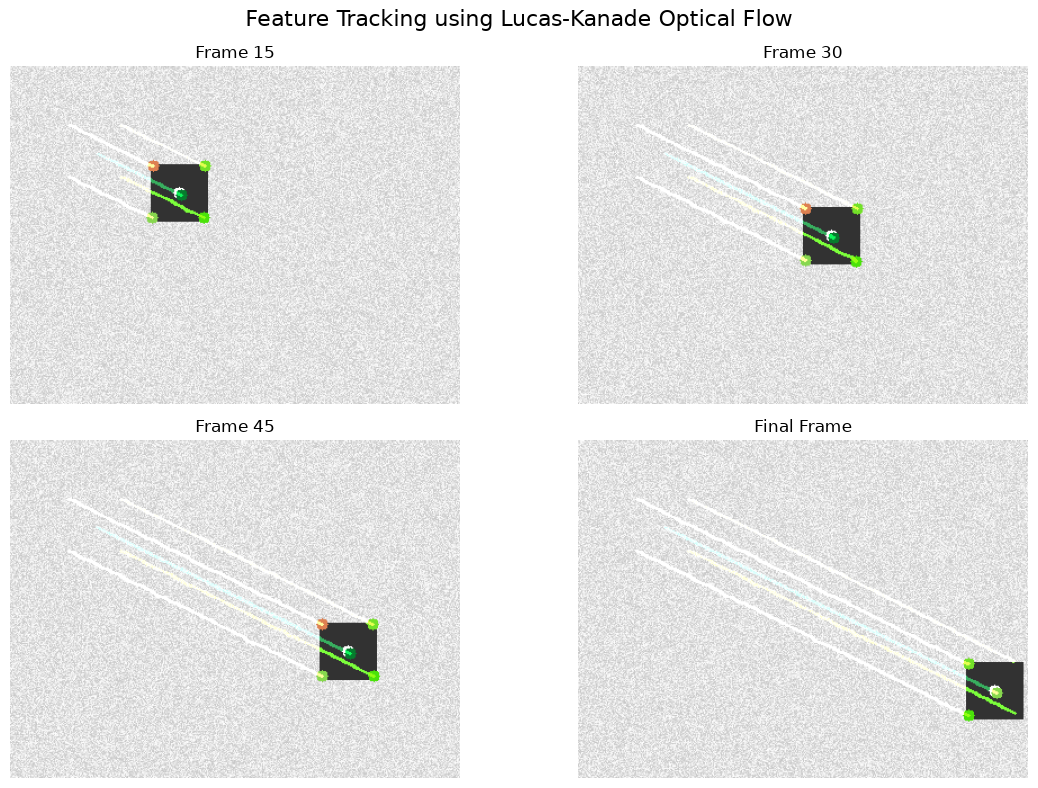

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. تولید یک ویدیوی شبیه‌سازی شده برای تست
# ==========================================
# ایجاد یک آرایه برای ذخیره فریم‌ها
frames = []
width, height = 400, 300
rect_size = 50

for i in range(60):
    # ایجاد یک پس‌زمینه خاکستری نویزدار (برای ایجاد بافت)
    frame = np.random.randint(200, 255, (height, width), dtype=np.uint8)
    
    # محاسبه موقعیت مربع در حال حرکت
    x = 50 + i * 5
    y = 50 + int(i * 2.5)
    
    # رسم یک مربع تیره با یک نقطه سفید داخل آن (به عنوان ویژگی مشخص)
    cv2.rectangle(frame, (x, y), (x + rect_size, y + rect_size), (50), -1)
    cv2.circle(frame, (x + 25, y + 25), 5, (255), -1)
    
    # تبدیل به BGR برای رسم خطوط رنگی در مرحله بعد
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    frames.append(frame_bgr)

# ==========================================
# 2. تنظیمات الگوریتم‌های تشخیص و ردیابی
# ==========================================
# پارامترهای الگوریتم Shi-Tomasi برای تشخیص ویژگی
feature_params = dict(maxCorners=100,
                      qualityLevel=0.3,
                      minDistance=7,
                      blockSize=7)

# پارامترهای الگوریتم Lucas-Kanade برای Optical Flow
lk_params = dict(winSize=(15, 15),
                 maxLevel=2,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

# رنگ‌های تصادفی برای رسم مسیر حرکت نقاط
color = np.random.randint(0, 255, (100, 3))

# ==========================================
# 3. اجرای سیستم ردیابی
# ==========================================
# گرفتن فریم اول و تشخیص ویژگی‌ها در آن
old_frame = frames[0]
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

# ایجاد یک تصویر خالی (Mask) برای رسم خطوط مسیر حرکت
mask = np.zeros_like(old_frame)

saved_keyframes = [] # برای نمایش در خروجی

for i in range(1, len(frames)):
    frame = frames[i]
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # محاسبه Optical Flow (موقعیت جدید نقاط)
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # انتخاب نقاطی که با موفقیت ردیابی شده‌اند (Status = 1)
    if p1 is not None:
        good_new = p1[st == 1]
        good_old = p0[st == 1]

    # رسم مسیر حرکت (Trajectory)
    for j, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[j].tolist(), 2)
        frame = cv2.circle(frame, (int(a), int(b)), 5, color[j].tolist(), -1)
    
    img = cv2.add(frame, mask)
    
    # ذخیره فریم‌های کلیدی برای نمایش (فریم‌های 15، 30، 45 و آخرین فریم)
    if i in [15, 30, 45, len(frames)-1]:
        saved_keyframes.append(img)

    # به‌روزرسانی فریم و نقاط قبلی برای مرحله بعد
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)

# ==========================================
# 4. نمایش فریم‌های کلیدی جهت ارزیابی
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Tracking using Lucas-Kanade Optical Flow', fontsize=16)

titles = ['Frame 15', 'Frame 30', 'Frame 45', 'Final Frame']
for idx, ax in enumerate(axes.flatten()):
    if idx < len(saved_keyframes):
        # تبدیل BGR به RGB برای نمایش درست رنگ‌ها در Matplotlib
        ax.imshow(cv2.cvtColor(saved_keyframes[idx], cv2.COLOR_BGR2RGB))
        ax.set_title(titles[idx])
        ax.axis('off')

plt.tight_layout()
plt.show()
